In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import numpy as np
import csv
import tkinter as tk
from tkinter import filedialog
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

#for the dialogue window when choosing the file
root = tk.Tk()
root.withdraw

from typing import Tuple

def wavelength_to_rgb(nm) -> Tuple:

    '''
    Takes a wavelength of visible light
    between 380 and 780 nanometres inclusive.
    Values outside this range will raise a ValueError.
    Returns a list of corresponding RGB values.
    Based on Dan Bruton's Fortran implementation.
    '''

    if nm < 380 or nm > 780:

        return (0, 0, 0)

    gamma = 0.8
    max_intensity = 255
    factor = 0

    rgb = {"R": 0, "G": 0, "B": 0}

    if 380 <= nm <= 439:
        rgb["R"] = -(nm - 440) / (440 - 380)
        rgb["G"] = 0.0
        rgb["B"] = 1.0
    elif 440 <= nm <= 489:
        rgb["R"] = 0.0
        rgb["G"] = (nm - 440) / (490 - 440)
        rgb["B"] = 1.0
    elif 490 <= nm <= 509:
        rgb["R"] = 0.0
        rgb["G"] = 1.0
        rgb["B"] = -(nm - 510) / (510 - 490)
    elif 510 <= nm <= 579:
        rgb["R"] = (nm - 510) / (580 - 510)
        rgb["G"] = 1.0
        rgb["B"] = 0.0
    elif 580 <= nm <= 644:
        rgb["R"] = 1.0
        rgb["G"] = -(nm - 645) / (645 - 580)
        rgb["B"] = 0.0
    elif 645 <= nm <= 780:
        rgb["R"] = 1.0
        rgb["G"] = 0.0
        rgb["B"] = 0.0

    if 380 <= nm <= 419:
        factor = 0.3 + 0.7 * (nm - 380) / (420 - 380)
    elif 420 <= nm <= 700:
        factor = 1.0
    elif 701 <= nm <= 780:
        factor = 0.3 + 0.7 * (780 - nm) / (780 - 700)

    if rgb["R"] > 0:
        rgb["R"] = int(max_intensity * ((rgb["R"] * factor) ** gamma))
    else:
        rgb["R"] = 0

    if rgb["G"] > 0:
        rgb["G"] = int(max_intensity * ((rgb["G"] * factor) ** gamma))
    else:
        rgb["G"] = 0

    if rgb["B"] > 0:
        rgb["B"] = int(max_intensity * ((rgb["B"] * factor) ** gamma))
    else:
        rgb["B"] = 0

    return (rgb["R"]/255, rgb["G"]/255, rgb["B"]/255)


This code snippet is meant to take files issued from the Carry 50 in the (lab number) lab at the COPL and transform the CSV output files into graphs for visualization and potentially presentation in papers or presentations. We currently have problems with the array slicing (the slicing indices need to be figured out and input manually, a data type check upon encoding could work but doesn't seem worth it at the moment)

In [2]:
def csv_2_data(path, stop):
    with open(path) as file:
        content = csv.reader(file)
        raw_data = []
        for i in content:
            raw_data += [i[:-1]]
    return np.array(raw_data[2:stop]).astype(float)


This cell asks for the file to be opened and extracts data from it. The stopping index for csv_2_data kind of has to be worked manually, to improved in the future.

In [ ]:
#file dialog file selection
file = filedialog.askopenfilename()
print(f"file opened:{file}")
root.withdraw()

#manual entry file selection
#file = "C:/DATA/Université/Maitrise/PN2026/XM260507-16.csv"

In [ ]:
#stop will dictate the stopping point in the array and thus the wavelengths shown
#This should get automated in the future. For now, 503 should work for traces covering from 300 to 800 nm
spectrum = csv_2_data(file, 503)
wavelengths = spectrum[:,-2]
raw_abs = spectrum[:,-1]

This cell finds peaks on the trace to help with analysis. The filtered trace used to find the peaks and the peaks themselves can be shown in the next code block when generating figures.

In [ ]:
#change the strength of the gaussian filter here! 2 seems enough for less noisy traces. 
#Set sigma to a very low value (0.001 is usually good) to essentially deactivate the filter
filter_sigma = 2
#This line actually creates the filtered clne of the data
fil_abs = gaussian_filter1d(raw_abs, sigma = filter_sigma)

#This function finds the setpoints corresponding to 
def data_2_peaks(wavel, counts, peaks):
    out = []
    for i in peaks:
        out += [[wavel[i], counts[i]]]
    return np.array(out)

#This calculates the position of peaks on the trace using the filtered data.
#Prominence is a measure of how high the peak is compared to its surroundings, useful for identifying noisy peaks
#Height is the minimum height of the peak, useful for the base noise on noisy traces
peaks, props = find_peaks(fil_abs, prominence = 0.005)

#This fetches the data points of the peaks on both the unfiltered and filtered data
raw_peaks = data_2_peaks(wavelengths, raw_abs, peaks)
fil_peaks = data_2_peaks(wavelengths, fil_abs, peaks)

print("Coordinates for the peaks of the spectrum (wavelength, counts):")
print(raw_peaks)

Coordinates for the peaks of the spectrum (wavelength, counts):
[[5.61012573e+02 1.95113625e-02]]


This cell simply plots the data onto a graph for visualization.

<function matplotlib.pyplot.show(close=None, block=None)>

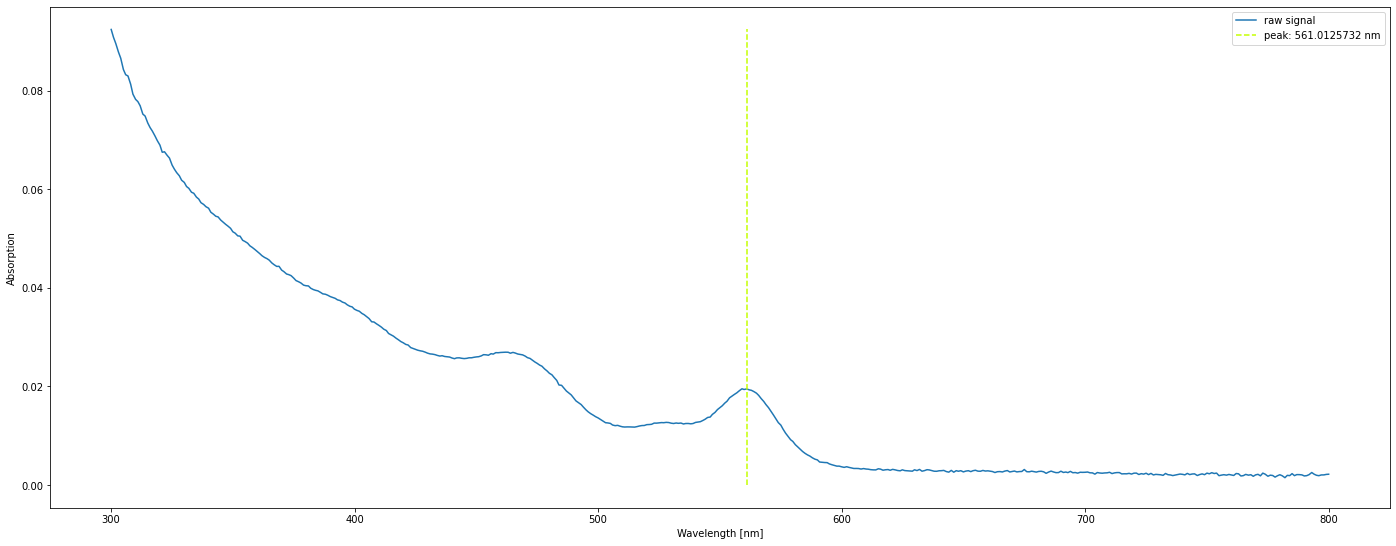

In [39]:
#These are the display options for the traces (write True or False)
see_filtered_trace = False
see_peak_lines = True

#This initiates the figure
fig, ax = plt.subplots(figsize=(24, 12))
fig.subplots_adjust(bottom=0.3)

#for drawing vertical lines
y_range = np.linspace(0, raw_abs.max())
ones = np.ones(y_range.shape)

#This draws the raw signal trace
plt.plot(wavelengths, raw_abs, label = "raw signal")

#This draws the filtered trace (if selected)
if see_filtered_trace:
    plt.plot(wavelengths, fil_abs, label = "Filtered signal")

#This draws the lines on top of the peaks
if see_peak_lines:
    for i in raw_peaks:
        plt.plot(ones*i[0], y_range, c = wavelength_to_rgb(i[0]), ls = "--", label = f"peak: {i[0]} nm")

#This finalizes the plot with a few adjustable options
#ax.tick_params("both", direction = "inout", top = True, right = True)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Absorption")
#plt.xlim(350, 800)
plt.legend()
plt.show

This small snippet is used to find the absorption value at a specified wavelength. Just input it in the corresponding value (in nm) and you will get a value for the absorption at that wavelength.

In [ ]:
def Abs_finder(spectrum, wavelength):
    ind = np.where(abs(spectrum[:, -2] - wavelength) <= 0.5)
    return float(spectrum[ind,-1])

wavelength_abs = 562.7
absorption = Abs_finder(spectrum, wavelength_abs)
print(f"Absoption at {wavelength_abs} nm : {absorption}")

Absoption at 562.7 nm : 0.01922318526


This cell was used to determine a factor between the concentration of two samples using the their respective absoprtion traces. It was specifically used for the Bi-dot's first synthesis (XM260513-01) and is extremely approximate in its function.

In [ ]:
def Abs_range_finder(spectrum, s_wl, e_wl):
    ind_s,  = np.where(abs(spectrum[:, -2] - s_wl) <= 0.5)
    ind_e,  = np.where(abs(spectrum[:, -2] - e_wl) <= 0.5)
    return spectrum[int(ind_e):int(ind_s),-1]

#Finds the absoption of the samples from their spectrums on the specified wavelength range
#This is the clear sample of quantum dots
spectrum_1 = csv_2_data("C:/DATA/Université/Maitrise/PN2026/XM260518-7.csv", 503)
absorption_1 = Abs_range_finder(spectrum_1, 400, 475)
#This is the milky sample of quantum dots
spectrum_2 = csv_2_data("C:/DATA/Université/Maitrise/PN2026/XM260518-6.csv", 503)
absorption_2 = Abs_range_finder(spectrum_2, 400, 475)

#This calculates an array of ratios, one for each data point on the range, and shows the mean and standard deviation of the ratio obtained
factor = absorption_1/absorption_2
print(np.mean(factor))
print(np.std(factor))


0.4502721472203854
0.012659065578317417


This prints both traces and the trace*ratio to see if the estimation seems appropriate

<function matplotlib.pyplot.show(close=None, block=None)>

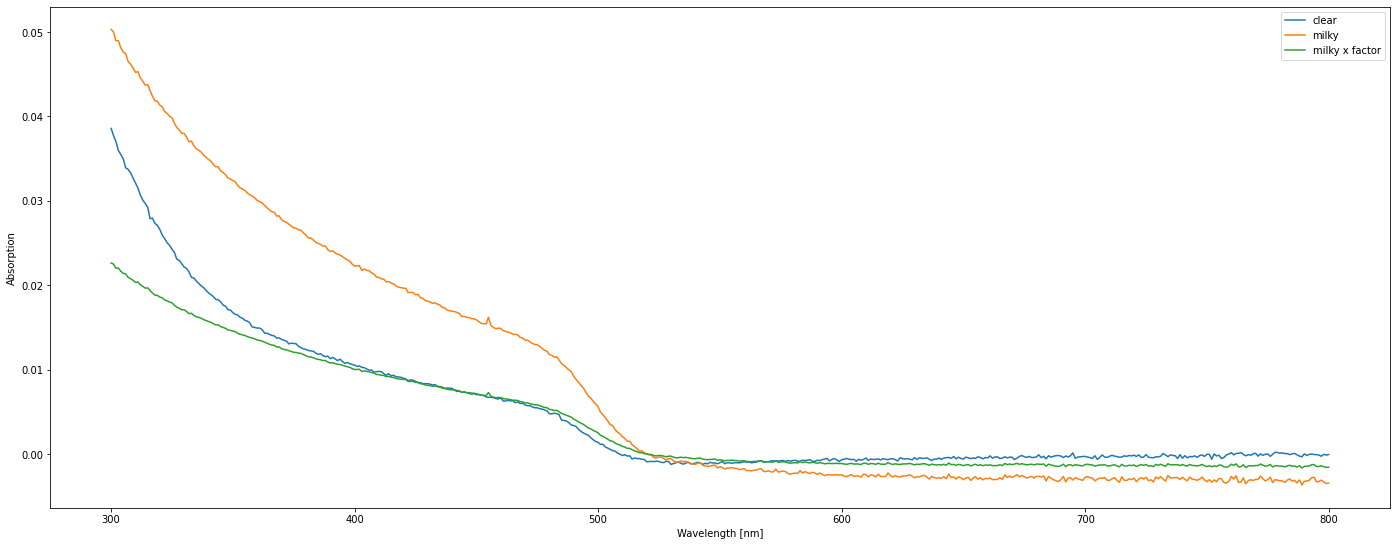

In [31]:
fig, ax = plt.subplots(figsize=(24, 12))
fig.subplots_adjust(bottom=0.3)

plt.plot(spectrum_1[:,-2], spectrum_1[:,-1], label = "clear")
plt.plot(spectrum_2[:,-2], spectrum_2[:,-1], label = "milky")
plt.plot(spectrum_2[:,-2], spectrum_2[:,-1]*0.45, label = "milky x factor")

#ax.tick_params("both", direction = "inout", top = True, right = True)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Absorption")
#plt.xlim(350, 500)
plt.legend()
plt.show